# Rates Volatility Modeling

# Vanilla Option Pricing Models

* **All we need is a terminal distribution** at the expiry $T$ if our goal is to price/hedge one single vanilla option
* **Simplist Assumption:** The underlying (say, a forward rate) follows a scaled Brownian motion: 
$$
dF_t = \sigma\,dW_t, 
$$
which leads to nice closed form formulas
* **The Reality:** Rates are not normally distributed. The market implied distribution has nonzero skewness and excess kurtosis
    * We need models, like SABR, that parameterize the first 4 moments of the distribution

# SABR

* $\alpha$ controls volatility (2nd moment)
* $\rho$ controls the implied vol skew (skewness of the distribution, the 3nd moment)
* $\nu$ (vol of vol) controls the implied vol convexity (kurtosis, the 4th moment)



In [1]:
import numpy as np

def _f_minus_k_ratio(f, k, beta):
    """Hagan's 2002 f minus k ratio - formula (B.67a)."""
    eps = 1e-07  # Numerical tolerance for f-k and beta
    if abs(f-k) > eps:
        if abs(1-beta) > eps:
            return (1 - beta) * (f - k) / (f**(1-beta) - k**(1-beta))
        else:
            return (f - k) / np.log(f / k)
    else:
        return k**beta


def _zeta_over_x_of_zeta(k, f, t, alpha, beta, rho, volvol):
    """Hagan's 2002 zeta / x(zeta) function - formulas (B.67a)-(B.67b)."""
    eps = 1e-07  # Numerical tolerance for zeta
    f_av = np.sqrt(f * k)
    zeta = volvol * (f - k) / (alpha * f_av**beta)
    if abs(zeta) > eps:
        return zeta / _x(rho, zeta)
    else:
        # The ratio converges to 1 when zeta approaches 0
        return 1.


def _x(rho, z):
    """Hagan's 2002 x function - formula (B.67b)."""
    a = (1 - 2*rho*z + z**2)**.5 + z - rho
    b = 1 - rho
    return np.log(a / b)


def normal_vol(k, f, t, alpha, beta, rho, volvol):
    """Hagan's 2002 SABR normal vol expansion - formula (B.67a)."""
    # We break down the complex formula into simpler sub-components
    f_av = np.sqrt(f * k)
    A = - beta * (2 - beta) * alpha**2 / (24 * f_av**(2 - 2 * beta))
    B = rho * alpha * volvol * beta / (4 * f_av**(1 - beta))
    C = (2 - 3 * rho**2) * volvol**2 / 24
    FMKR = _f_minus_k_ratio(f, k, beta)
    ZXZ = _zeta_over_x_of_zeta(k, f, t, alpha, beta, rho, volvol)
    # Aggregate all components into actual formula (B.67a)
    v_n = alpha * FMKR * ZXZ * (1 + (A + B + C) * t)
    return v_n

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pandas import DataFrame
from ipywidgets import interact

import warnings
warnings.filterwarnings('ignore')

@interact(alpha=(0.001, 0.01, 0.001), rho=(-0.99, 0.99, 0.1), volvol=(0.01, 1, 0.1))
def plot(alpha=0.01, rho=0., volvol=0.6):
    beta = 0.6
    F = 0.1
    T = 1
    a = 0.08
    b = 0.12

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    def call(K, F, T, A=1):
        iv = normal_vol(K, F, T, alpha, beta, rho, volvol)
        d = (F-K)/(iv*np.sqrt(T))
        return A*iv*np.sqrt(T)*(norm.pdf(d) + d*norm.cdf(d))

    def put(K, F, T, A=1):
        return call(K, F, T, A) + A*(K-F)

    DataFrame([(K, normal_vol(K, F, T, alpha, beta, rho, volvol)) for K in np.arange(a, b, 0.001)], columns=['K', 'Implied Vol']).set_index('K').plot(style='-.', legend=None, ax=ax1)
    ax1.set(ylim=(-0.001, 0.015), title='SABR Normal Implied Vol')

    DataFrame([(K, call(K, F, T) if K>F else put(K, F, T)) for K in np.arange(a, b, 0.001)], columns=['K', 'OTM Options']).set_index('K').plot(style='-.', legend=None, ax=ax2)
    ax2.set(ylim=(-0.0001, 0.0012), title='OTM Option PV')
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='alpha', max=0.01, min=0.001, step=0.001), FloatSlid…

# The Challenge

* In a multi-currency or multi-tenor book, we don't just price one option; we manage the joint movement of the entire curve.
* option pricing input: level, vol, skew
* 

# Heath–Jarrow–Morton (HJM) Framework

* Under the risk-neutral probability, once forward rate vol is determined, so is its drift 
* $f(t, T)$: Instantaneous forward rate
    * Forward rate for the reference period $[T, T+\epsilon]$ observed at $t$
* $\sigma(t, T)$: Forward rate vol
$$
df(t, T) = O(dt) + \sigma(t, T)\,d\widetilde W(t), \qquad t<T
$$
* Think of a fixed $T$, say 10Y
$$
df_{\text{10Y}}(t) = O(dt) + \sigma_{\text{10Y}}(t)\,d\widetilde W(t), \qquad t<\text{10Y}
$$

# Heath–Jarrow–Morton (HJM) Framework (Cont.)

$$
df_{\text{10Y}}(t) = O(dt) + \sigma_{\text{10Y}}(t)\,d\widetilde W(t), \qquad t<\text{10Y}
$$

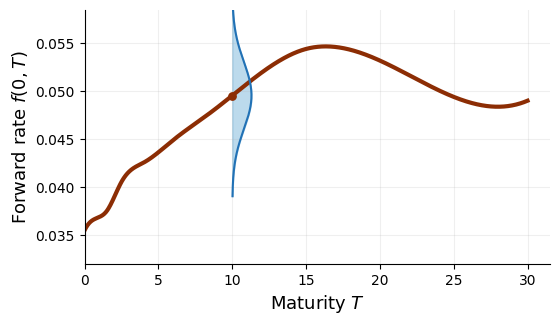

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

fwd_knots = np.array([0.0, 0.5, 1.5, 2.5, 4.0, 6.0, 8.5, 15.0, 25.0, 30.0])
fwd_vals  = np.array([0.0355, 0.0365, 0.0375, 0.04055, 0.04255, 0.0449, 0.04773, 0.0544, 0.0494, 0.0490])
cs = CubicSpline(fwd_knots, fwd_vals, bc_type='not-a-knot')
maturity = np.linspace(0, 30, 1201)
forward_curve = cs(maturity)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(maturity, forward_curve, color='#8c2d04', linewidth=3)

pillars = np.array([10.0])
pillar_forwards = cs(pillars)
vols = np.array([0.0035])
width_scale = 1.3

for pillar, center, vol in zip(pillars, pillar_forwards, vols):
    move = np.linspace(-3 * vol, 3 * vol, 250)
    density = np.exp(-0.5 * (move / vol) ** 2)
    density /= density.max()
    x_right = pillar + width_scale * density
    ax.fill_betweenx(center + move, pillar, x_right, color='#6baed6', alpha=0.45)
    ax.plot(x_right, center + move, color='#2171b5', linewidth=1.5)
    ax.scatter([pillar], [center], color='#8c2d04', s=28, zorder=3)

ax.set_xlim(0, 31.5)
ax.set_ylim(0.032, 0.0585)
ax.set_xlabel('Maturity $T$', fontsize=13)
ax.set_ylabel('Forward rate $f(0,T)$', fontsize=13)
ax.grid(alpha=0.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()


# Heath–Jarrow–Morton (HJM) Framework (Cont..)

$$
df(t, T) = O(dt) + \sigma(t, T)\,d\widetilde W(t), \qquad t<T
$$

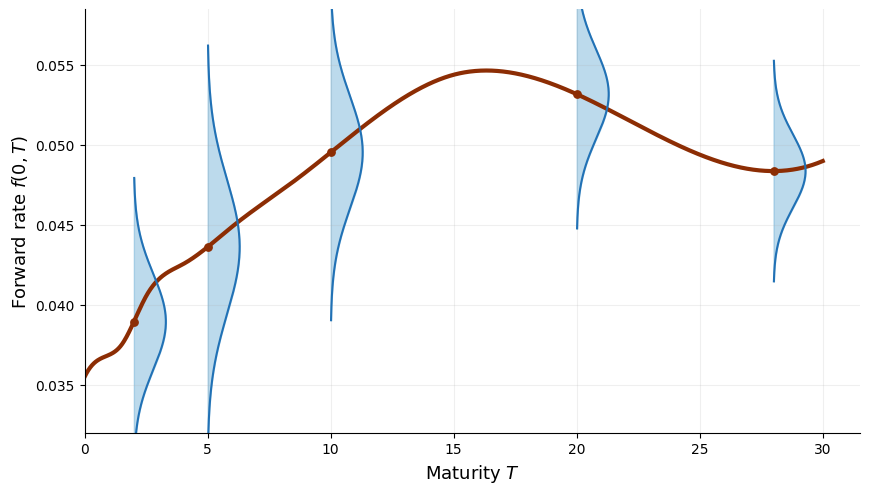

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

fwd_knots = np.array([0.0, 0.5, 1.5, 2.5, 4.0, 6.0, 8.5, 15.0, 25.0, 30.0])
fwd_vals  = np.array([0.0355, 0.0365, 0.0375, 0.04055, 0.04255, 0.0449, 0.04773, 0.0544, 0.0494, 0.0490])
cs = CubicSpline(fwd_knots, fwd_vals, bc_type='not-a-knot')
maturity = np.linspace(0, 30, 1201)
forward_curve = cs(maturity)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(maturity, forward_curve, color='#8c2d04', linewidth=3)

pillars = np.array([2, 5, 10, 20, 28], dtype=float)
pillar_forwards = cs(pillars)
vols = np.array([0.0030, 0.0042, 0.0035, 0.0028, 0.0023])
width_scale = 1.3

for pillar, center, vol in zip(pillars, pillar_forwards, vols):
    move = np.linspace(-3 * vol, 3 * vol, 250)
    density = np.exp(-0.5 * (move / vol) ** 2)
    density /= density.max()
    x_right = pillar + width_scale * density
    ax.fill_betweenx(center + move, pillar, x_right, color='#6baed6', alpha=0.45)
    ax.plot(x_right, center + move, color='#2171b5', linewidth=1.5)
    ax.scatter([pillar], [center], color='#8c2d04', s=28, zorder=3)

ax.set_xlim(0, 31.5)
ax.set_ylim(0.032, 0.0585)
ax.set_xlabel('Maturity $T$', fontsize=13)
ax.set_ylabel('Forward rate $f(0,T)$', fontsize=13)
ax.grid(alpha=0.2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()


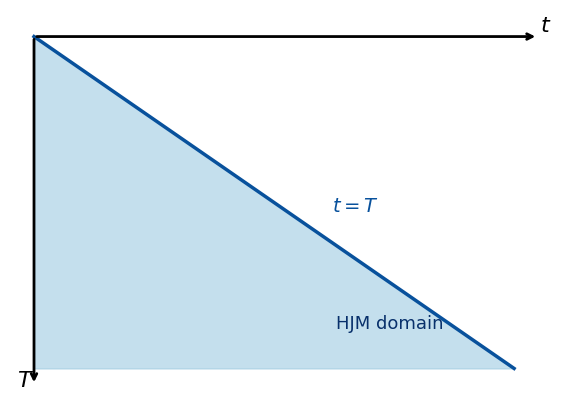

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Use y = -T so the T-axis points downward on the page.
t_max = 10
T_max = 10

t = np.linspace(0, t_max, 400)
y_line = -t

# Shade the region below the line t = T in the fourth quadrant.
ax.fill_between(t, y_line, -T_max, color="#9ecae1", alpha=0.6)
ax.plot(t, y_line, color="#08519c", linewidth=2.5)

# Clean frame and draw custom axes.
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(-0.5, t_max + 0.8)
ax.set_ylim(-T_max - 0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])

ax.annotate("", xy=(t_max + 0.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))
ax.annotate("", xy=(0, -T_max - 0.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2, color="black"))

ax.text(t_max + 0.55, 0.15, r"$t$", fontsize=16)
ax.text(-0.35, -T_max - 0.55, r"$T$", fontsize=16)
ax.text(6.2, -5.3, r"$t = T$", color="#08519c", fontsize=14)
ax.text(6.3, -8.8, "HJM domain", color="#08306b", fontsize=13)

plt.show()

In [2]:
# %matplotlib inline
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

@interact(m=(-2.0, 2.0), b=(-3, 3, 0.5))
def f(m=0, b=0):
    plt.figure(2)
    x = np.linspace(-10, 10, num=1000)
    plt.plot(x, m * x + b)
    plt.ylim(-5, 5)
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='m', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…